# Reproductive Health Analysis: Synthea Synthetic Population
### Female Patients Aged 18–45 | Washington State

**Author:** Charlie Eddington  
**Date:** March 2026  
**Tools:** Python · pandas · SQLite · Plotly  

This notebook analyzes reproductive health outcomes in a synthetic patient population 
generated by [Synthea](https://synthetichealth.github.io/synthea/)

In [2]:
import pandas as pd
import sqlite3
from pathlib import Path

## 1. Data Loading

All Synthea CSV exports are loaded dynamically into an in-memory SQLite database. 
Using SQLite allows us to write readable SQL queries throughout the analysis without 
requiring a database server.

In [4]:
DATA_DIR = Path("../Womens_Health_Analysis/data/raw/csv")
DB_PATH = Path("../db/womens_health.db")


In [5]:
# Connect — creates the file if it doesn't exist
conn = sqlite3.connect(DB_PATH)

In [61]:
# ── LOAD: All Synthea CSVs ────────────────────────────────────────────────
import os

csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]

for file in csv_files:
    table_name = "raw_" + file.replace(".csv", "")
    df = pd.read_csv(DATA_DIR / file, low_memory=False)
    df.to_sql(table_name, conn, if_exists="replace", index=False)

# Confirm
for file in csv_files:
    table_name = "raw_" + file.replace(".csv", "")
    count = pd.read_sql(f"SELECT COUNT(*) as rows FROM {table_name}", conn).iloc[0,0]
    print(f"{table_name}: {count:,} rows")

raw_medications: 87,164 rows
raw_providers: 997 rows
raw_payer_transitions: 163,031 rows
raw_imaging_studies: 12,062 rows
raw_supplies: 74,155 rows
raw_payers: 10 rows
raw_claims: 366,680 rows
raw_allergies: 6,080 rows
raw_procedures: 808,153 rows
raw_organizations: 997 rows
raw_conditions: 143,032 rows
raw_careplans: 20,237 rows
raw_encounters: 279,516 rows
raw_devices: 17,467 rows
raw_immunizations: 59,412 rows
raw_claims_transactions: 3,825,029 rows
raw_patients: 5,141 rows
raw_observations: 1,579,546 rows


In [6]:
# Load CSVs one at a time option  
#patients    = pd.read_csv(DATA_DIR / "patients.csv")
#conditions  = pd.read_csv(DATA_DIR / "conditions.csv")
#medications = pd.read_csv(DATA_DIR / "medications.csv")
#encounters  = pd.read_csv(DATA_DIR / "encounters.csv")
# Write to SQLite as raw tables
#patients.to_sql("raw_patients", conn, if_exists="replace", index=False)
#conditions.to_sql("raw_conditions", conn, if_exists="replace", index=False)
#medications.to_sql("raw_medications", conn, if_exists="replace", index=False)
#encounters.to_sql("raw_encounters", conn, if_exists="replace", index=False

# Confirm
#for table in ["raw_patients", "raw_conditions", "raw_medications", "raw_encounters"]:
#    count = pd.read_sql(f"SELECT COUNT(*) as rows FROM {table}", conn).iloc[0,0]
#    print(f"{table}: {count:,} rows")

In [8]:
# Confirm
for table in ["raw_patients", "raw_conditions", "raw_medications", "raw_encounters"]:
    count = pd.read_sql(f"SELECT COUNT(*) as rows FROM {table}", conn).iloc[0,0]
    print(f"{table}: {count:,} rows")

raw_patients: 5,141 rows
raw_conditions: 143,032 rows
raw_medications: 87,164 rows
raw_encounters: 279,516 rows


In [64]:
query = """select * from raw_procedures limit 10  """

results = pd.read_sql(query, conn)
print (results.to_string())

                  START                  STOP                               PATIENT                             ENCOUNTER     SYSTEM       CODE                                             DESCRIPTION  BASE_COST REASONCODE REASONDESCRIPTION
0  2016-03-10T17:05:47Z  2016-03-10T17:17:46Z  ba419d35-0dfe-8af7-347c-eebf02485a56  ba419d35-0dfe-8af7-1f3b-e3c3f8e0167f  SNOMED-CT   76601001                     Intramuscular injection (procedure)    1380.67       None              None
1  2016-06-09T17:05:47Z  2016-06-09T17:19:19Z  ba419d35-0dfe-8af7-347c-eebf02485a56  ba419d35-0dfe-8af7-2876-2cc78478aac9  SNOMED-CT   76601001                     Intramuscular injection (procedure)    1191.89       None              None
2  2016-09-08T17:05:47Z  2016-09-08T17:19:01Z  ba419d35-0dfe-8af7-347c-eebf02485a56  ba419d35-0dfe-8af7-1ae3-8f315376ea1b  SNOMED-CT   76601001                     Intramuscular injection (procedure)    2719.96       None              None
3  2016-12-08T17:05:47Z  2016-12-08T17:1

In [13]:
query = """
SELECT DESCRIPTION, COUNT(*) as n, count(*)*100.00/ sum(count(*)) OVER()  as percent_total
FROM raw_conditions
WHERE DESCRIPTION LIKE '%pregnan%'
   OR DESCRIPTION LIKE '%miscarr%'
   OR DESCRIPTION LIKE '%eclamp%'
   OR DESCRIPTION LIKE '%anemia%'
   OR DESCRIPTION LIKE '%inferti%'
   OR DESCRIPTION LIKE '%abuse%'
GROUP BY DESCRIPTION
ORDER BY n DESC
"""

results = pd.read_sql(query, conn)
print(results.to_string())


                                             DESCRIPTION      n  percent_total
0                             Normal pregnancy (finding)  10602      55.178516
1             Victim of intimate partner abuse (finding)   2137      11.122098
2                                      Anemia (disorder)   1644       8.556261
3      Past pregnancy history of miscarriage (situation)   1495       7.780785
4              Miscarriage in first trimester (disorder)    931       4.845425
5                      Eclampsia in pregnancy (disorder)    554       2.883314
6                               Pre-eclampsia (disorder)    553       2.878110
7                        Complete miscarriage (disorder)    549       2.857292
8             Miscarriage in second trimester (disorder)    315       1.639430
9                        Dependent drug abuse (disorder)    241       1.254294
10                            Tubal pregnancy (disorder)    111       0.577704
11    Complication occurring during pregnancy (disor

## 2. Patient Cohort Filter

We filter to female patients aged 18–45 — the standard reproductive age range used 
in obstetric and maternal health research. Age groups are banded into 5-year intervals 
to align with CDC reporting standards.

In [14]:
# ── CLEAN & FILTER: Patients ──────────────────────────────────────────────
filtered_patients = pd.read_sql("""
    SELECT
        Id,
        BIRTHDATE,
        GENDER,
        RACE,
        ETHNICITY,
        CAST(strftime('%Y', 'now') - strftime('%Y', BIRTHDATE) AS INTEGER) AS age,
        CASE
            WHEN CAST(strftime('%Y', 'now') - strftime('%Y', BIRTHDATE) AS INTEGER) BETWEEN 18 AND 24 THEN '18-24'
            WHEN CAST(strftime('%Y', 'now') - strftime('%Y', BIRTHDATE) AS INTEGER) BETWEEN 25 AND 29 THEN '25-29'
            WHEN CAST(strftime('%Y', 'now') - strftime('%Y', BIRTHDATE) AS INTEGER) BETWEEN 30 AND 34 THEN '30-34'
            WHEN CAST(strftime('%Y', 'now') - strftime('%Y', BIRTHDATE) AS INTEGER) BETWEEN 35 AND 39 THEN '35-39'
            WHEN CAST(strftime('%Y', 'now') - strftime('%Y', BIRTHDATE) AS INTEGER) BETWEEN 40 AND 45 THEN '40-45'
        END AS age_group
    FROM raw_patients
    WHERE GENDER = 'F'
    AND CAST(strftime('%Y', 'now') - strftime('%Y', BIRTHDATE) AS INTEGER) BETWEEN 18 AND 45
""", conn)

filtered_patients.to_sql("patients", conn, if_exists="replace", index=False)
print(f"Patients after filter: {len(filtered_patients):,}")

Patients after filter: 5,141


In [15]:
# ── EXPLORE: What reproductive-adjacent codes exist in our cohort? ─────────
actual_codes = pd.read_sql("""
    SELECT
        CODE,
        DESCRIPTION,
        COUNT(*) as count
    FROM raw_conditions
    WHERE PATIENT IN (SELECT Id FROM patients)
    GROUP BY CODE, DESCRIPTION
    ORDER BY count DESC
""", conn)

print(actual_codes.to_string(index=False))

             CODE                                                                    DESCRIPTION  count
        314529007                                              Medication review due (situation)  20824
         72892002                                                     Normal pregnancy (finding)  10602
         66383009                                                          Gingivitis (disorder)   9483
         73595000                                                               Stress (finding)   9272
        160903007                                                 Full-time employment (finding)   8847
        444814009                                                     Viral sinusitis (disorder)   5459
        160904001                                                 Part-time employment (finding)   4833
        423315002                                               Limited social contact (finding)   3510
        422650009                                               

## 3. Condition Filtering

Conditions are filtered to clinically relevant SNOMED-CT codes covering reproductive 
health, pregnancy complications, and intimate partner violence. 

SNOMED codes were validated against the actual data export before inclusion — only 
codes present in this population are included. SDOH codes are separated into their 
own table for independent analysis.

In [37]:

REPRO_CODES = {
    # Pregnancy
    72892002:  "Normal pregnancy",
    47200007:  "High risk pregnancy",
    # Complications
    198992004: "Eclampsia in pregnancy",
    398254007: "Pre-eclampsia",
    609496007: "Complication occurring during pregnancy",
    44054006:  "Gestational diabetes",
    271737000: "Anemia",
    # Miscarriage
    19169002:  "Miscarriage in first trimester",
    85116003:  "Miscarriage in second trimester",
    156073000: "Complete miscarriage",
    161744009: "Past pregnancy history of miscarriage",
    35999006:  "Blighted ovum",
    267253006: "Fetus with chromosomal abnormality",
    # Ectopic
    79586000:  "Tubal pregnancy",
    # Intimate partner abuse
    706893006: "Victim of intimate partner abuse",
    424393004: "Reports of violence in the environment",
    # Infertility
    707577004: "Female infertility due to cystic fibrosis",
}

SDOH_CODES = {
    # Employment
    160903007: "Full-time employment",
    160904001: "Part-time employment",
    73438004:  "Unemployed",
    741062008: "Not in labor force",
    # Education
    224299000: "Received higher education",
    473461003: "Educated to high school level",
    224295006: "Only received primary school education",
    # Isolation & housing
    422650009: "Social isolation",
    423315002: "Limited social contact",
    105531004: "Housing unsatisfactory",
    # Transport
    266934004: "Transport problem",
    713458007: "Lack of access to transportation",
}



In [38]:
pd.read_sql("SELECT * FROM raw_conditions LIMIT 2", conn)

,START,STOP,PATIENT,ENCOUNTER,SYSTEM,CODE,DESCRIPTION
0,2015-10-16,2016-09-30,46976cf7-b0bf-be20-39a5-9f425a52886d,46976cf7-b0bf-be20-3e2b-c22b6dc2b087,SNOMED-CT,314529007,Medication review due (situation)
1,2010-12-30,2017-02-02,ba419d35-0dfe-8af7-347c-eebf02485a56,ba419d35-0dfe-8af7-85ee-fc4743beef37,SNOMED-CT,314529007,Medication review due (situation)


In [87]:
all_codes = set(REPRO_CODES) | set(SDOH_CODES) 
placeholders = ",".join(f"'{c}'" for c in all_codes)

conditions = pd.read_sql(f"""
    SELECT
        c.PATIENT,
        c.START,
        c.STOP,
        c.CODE,
        c.DESCRIPTION
    FROM raw_conditions c
    INNER JOIN patients p ON c.PATIENT = p.Id
    WHERE c.CODE IN ({placeholders})
""", conn)

conditions.dtypes

PATIENT        object
START          object
STOP           object
CODE            int64
DESCRIPTION    object
dtype: object

In [88]:
# Split into repro and SDOH tables
repro_conditions = conditions[conditions["CODE"].isin(REPRO_CODES.keys())].copy()
sdoh_conditions  = conditions[conditions["CODE"].isin(SDOH_CODES.keys())].copy()

repro_conditions.to_sql("conditions", conn, if_exists="replace", index=False)
sdoh_conditions.to_sql("sdoh", conn, if_exists="replace", index=False)

print(f"Reproductive health conditions: {len(repro_conditions):,}")
print(f"SDOH conditions:                {len(sdoh_conditions):,}")

Reproductive health conditions: 21,066
SDOH conditions:                31,389


## 4. Derived Flags

Binary flags are derived for each patient to enable cohort-level analysis:

- `pregnancy_flag` — any pregnancy-related condition recorded
- `complication_flag` — any obstetric complication recorded  
- `miscarriage_flag` — any pregnancy loss recorded
- `ectopic_flag` — tubal or ectopic pregnancy recorded
- `ipv_flag` — intimate partner violence recorded

> ⚠️ **Note:** Flag rates in this dataset reflect known Synthea data quality issues. 
> See the limitations section for details.

In [43]:
# ── DERIVED FLAGS ─────────────────────────────────────────────────────────
patient_flags = pd.read_sql("""
    SELECT
        p.Id,
        p.age,
        p.age_group,
        p.RACE,
        p.ETHNICITY,
        MAX(CASE WHEN c.CODE IN (72892002, 47200007, 65727000) THEN 1 ELSE 0 END) AS pregnancy_flag,
        MAX(CASE WHEN c.CODE IN (198992004, 398254007, 609496007, 44054006, 271737000) THEN 1 ELSE 0 END) AS complication_flag,
        MAX(CASE WHEN c.CODE IN (19169002, 85116003, 156073000, 161744009, 35999006, 267253006) THEN 1 ELSE 0 END) AS miscarriage_flag,
        MAX(CASE WHEN c.CODE IN (79586000) THEN 1 ELSE 0 END) AS ectopic_flag,
        MAX(CASE WHEN c.CODE IN (706893006, 424393004) THEN 1 ELSE 0 END) AS ipv_flag
    FROM patients p
    LEFT JOIN conditions c ON p.Id = c.PATIENT
    GROUP BY p.Id, p.age, p.age_group, p.RACE, p.ETHNICITY
""", conn)

patient_flags.to_sql("patient_flags", conn, if_exists="replace", index=False)

print(f"Total patients:       {len(patient_flags):,}")
print(f"Pregnant:             {patient_flags.pregnancy_flag.sum():,}")
print(f"With complications:   {patient_flags.complication_flag.sum():,}")
print(f"With miscarriage:     {patient_flags.miscarriage_flag.sum():,}")
print(f"Ectopic:              {patient_flags.ectopic_flag.sum():,}")
print(f"IPV:                  {patient_flags.ipv_flag.sum():,}")

Total patients:       5,141
Pregnant:             4,011
With complications:   2,229
With miscarriage:     1,499
Ectopic:              109
IPV:                  2,602


## 5. Analysis

### 5.1 Pregnancy Outcomes by Age Group

Pregnancy, complication, miscarriage, and ectopic rates are calculated as a percentage 
of total patients within each age group. Complication and miscarriage rates are also 
expressed as a percentage of pregnant patients to isolate the effect of age on outcomes 
independent of overall pregnancy rate.

Clinically, we expect complications and miscarriage to rise with age due to declining 
egg quality, increased chromosomal abnormalities, and higher prevalence of comorbidities 
in older patients.

In [44]:
# ── SQL ANALYSIS 1: Pregnancy Outcomes by Age Group ───────────────────────
pregnancy_outcomes = pd.read_sql("""
    SELECT
        p.age_group,
        COUNT(DISTINCT p.Id)                                           AS total_patients,
        SUM(p.pregnancy_flag)                                          AS pregnant,
        SUM(p.complication_flag)                                       AS with_complications,
        SUM(p.miscarriage_flag)                                        AS with_miscarriage,
        SUM(p.ectopic_flag)                                            AS ectopic,
        ROUND(100.0 * SUM(p.pregnancy_flag) / COUNT(DISTINCT p.Id), 1)       AS pct_pregnant,
        ROUND(100.0 * SUM(p.complication_flag) / NULLIF(SUM(p.pregnancy_flag), 0), 1) AS pct_complicated,
        ROUND(100.0 * SUM(p.miscarriage_flag) / NULLIF(SUM(p.pregnancy_flag), 0), 1)  AS pct_miscarriage,
        ROUND(100.0 * SUM(p.ectopic_flag) / NULLIF(SUM(p.pregnancy_flag), 0), 1)      AS pct_ectopic
    FROM patient_flags p
    GROUP BY p.age_group
    ORDER BY p.age_group
""", conn)

print(pregnancy_outcomes.to_string(index=False))

age_group  total_patients  pregnant  with_complications  with_miscarriage  ectopic  pct_pregnant  pct_complicated  pct_miscarriage  pct_ectopic
    18-24            1138       587                 189                79        7          51.6             32.2             13.5          1.2
    25-29             976       848                 391               183       20          86.9             46.1             21.6          2.4
    30-34             932       884                 511               297       22          94.8             57.8             33.6          2.5
    35-39             976       856                 562               418       25          87.7             65.7             48.8          2.9
    40-45            1119       836                 576               522       35          74.7             68.9             62.4          4.2


### 5.2 Miscarriage Rate by Age Group

Miscarriage rate is expressed as a percentage of pregnant patients within each age 
group. This is compared against CDC/ACOG benchmark rates to evaluate how well Synthea 
represents real-world pregnancy loss patterns.

Real-world miscarriage risk increases significantly after age 35, driven primarily by 
chromosomal abnormalities in the embryo (ACOG, 2023).

In [45]:
# ── SQL ANALYSIS 2: Miscarriage Rate by Age Group ─────────────────────────
miscarriage_rates = pd.read_sql("""
    SELECT
        p.age_group,
        COUNT(DISTINCT p.Id)                                                    AS total_patients,
        SUM(p.miscarriage_flag)                                                 AS miscarriages,
        ROUND(100.0 * SUM(p.miscarriage_flag) / COUNT(DISTINCT p.Id), 1)       AS rate_overall,
        ROUND(100.0 * SUM(p.miscarriage_flag) / NULLIF(SUM(p.pregnancy_flag), 0), 1) AS rate_of_pregnant
    FROM patient_flags p
    GROUP BY p.age_group
    ORDER BY p.age_group
""", conn)

print(miscarriage_rates.to_string(index=False))

age_group  total_patients  miscarriages  rate_overall  rate_of_pregnant
    18-24            1138            79           6.9              13.5
    25-29             976           183          18.8              21.6
    30-34             932           297          31.9              33.6
    35-39             976           418          42.8              48.8
    40-45            1119           522          46.6              62.4


### 5.3 Obstetric Complication Distribution

The distribution of specific obstetric conditions is calculated as a percentage of 
all pregnant patients. This provides a snapshot of which complications are most 
prevalent in the synthetic population and highlights where Synthea's generation 
diverges from real-world epidemiology.

In [46]:
# ── SQL ANALYSIS 3: Obstetric Complication Distribution ───────────────────
complication_dist = pd.read_sql("""
    SELECT
        c.DESCRIPTION,
        c.CODE,
        COUNT(DISTINCT c.PATIENT)                                               AS patients_affected,
        ROUND(100.0 * COUNT(DISTINCT c.PATIENT) / (
            SELECT COUNT(DISTINCT Id) FROM patient_flags WHERE pregnancy_flag = 1
        ), 1)                                                                   AS pct_of_pregnant
    FROM conditions c
    INNER JOIN patient_flags p ON c.PATIENT = p.Id
    WHERE c.CODE IN (
        198992004, 398254007, 609496007,
        44054006, 271737000, 19169002,
        85116003, 156073000, 35999006,
        267253006, 79586000
    )
    AND p.pregnancy_flag = 1
    GROUP BY c.DESCRIPTION, c.CODE
    ORDER BY patients_affected DESC
""", conn)

print(complication_dist.to_string(index=False))

                                       DESCRIPTION      CODE  patients_affected  pct_of_pregnant
                                 Anemia (disorder) 271737000               1455             36.3
         Miscarriage in first trimester (disorder)  19169002                823             20.5
                 Eclampsia in pregnancy (disorder) 198992004                527             13.1
                   Complete miscarriage (disorder) 156073000                518             12.9
                          Pre-eclampsia (disorder) 398254007                517             12.9
        Miscarriage in second trimester (disorder)  85116003                304              7.6
                          Blighted ovum (disorder)  35999006                256              6.4
     Fetus with chromosomal abnormality (disorder) 267253006                183              4.6
                        Tubal pregnancy (disorder)  79586000                109              2.7
               Diabetes mellit

### ⚠️ Data Quality Note: Eclampsia Over-Representation

Before interpreting complication rates, it is important to understand a known data 
quality issue in this dataset affecting pre-eclampsia and eclampsia rates.

In [93]:

synthea_bug_note = """
## ⚠️ Known Synthea Data Quality Issue: Eclampsia Over-Representation

Due to two bugs in Synthea's `pregnancy.json` module, this dataset contains
significant inaccuracies in pre-eclampsia and eclampsia rates:

**Bug 1 — Week 32 (encounter timing):** The `Develop_Pre_Eclampsia` ConditionOnset
fired before the `Week_32_Visit` encounter was open, causing all pre-eclampsia
diagnoses to be silently dropped. This resulted in **zero pre-eclampsia cases**
in unpatched Synthea exports.

**Bug 2 — Week 36 (logic error):** `Pre_Eclampsia_Check` unconditionally funnelled
all patients — both those with existing pre-eclampsia and those without — into
`Develop_Eclampsia`. This caused **100% of the 8% pre-eclampsia branch to be
recorded as eclampsia**.

### Observed in this dataset:
- Pre-eclampsia:  {pe_count:,} patients ({pe_pct:.1f}% of pregnant)
- Eclampsia:      {ec_count:,} patients ({ec_pct:.1f}% of pregnant)
- Pre-eclampsia to eclampsia ratio: {ratio:.1f}:1 (expected ~200:1 in US populations)

### CDC / WHO Benchmarks (US population):
- Pre-eclampsia:  5–7% of pregnancies (CDC, 2022)
- Eclampsia:      0.016–0.1% of deliveries / ~0.3–0.8% of pre-eclampsia cases
                  (Fishel Bartal & Sibai, AJOG 2022; WHO Fact Sheet, 2025)

### These bugs have been fixed in the Synthea pregnancy module (PR pending).
Results in this notebook reflect **pre-fix data** and should be interpreted
with this limitation in mind.

Sources:
- CDC: https://blogs.cdc.gov/genomics/2022/10/25/preeclampsia/
- WHO: https://www.who.int/news-room/fact-sheets/detail/pre-eclampsia
- Fishel Bartal M, Sibai BM. Eclampsia in the 21st century.
  Am J Obstet Gynecol. 2022. https://www.ajog.org/article/S0002-9378(20)31128-5/fulltext
"""

# Pull live metrics from the data
pe_count = complication_dist.loc[complication_dist["CODE"] == 398254007, "patients_affected"].values[0]
ec_count = complication_dist.loc[complication_dist["CODE"] == 198992004, "patients_affected"].values[0]
pregnant  = patient_flags["pregnancy_flag"].sum()
pe_pct    = 100.0 * pe_count / pregnant
ec_pct    = 100.0 * ec_count / pregnant
ratio     = pe_count / ec_count if ec_count > 0 else float("inf")

print(synthea_bug_note.format(
    pe_count=pe_count,
    ec_count=ec_count,
    pe_pct=pe_pct,
    ec_pct=ec_pct,
    ratio=ratio
))


## ⚠️ Known Synthea Data Quality Issue: Eclampsia Over-Representation

Due to two bugs in Synthea's `pregnancy.json` module, this dataset contains
significant inaccuracies in pre-eclampsia and eclampsia rates:

**Bug 1 — Week 32 (encounter timing):** The `Develop_Pre_Eclampsia` ConditionOnset
fired before the `Week_32_Visit` encounter was open, causing all pre-eclampsia
diagnoses to be silently dropped. This resulted in **zero pre-eclampsia cases**
in unpatched Synthea exports.

**Bug 2 — Week 36 (logic error):** `Pre_Eclampsia_Check` unconditionally funnelled
all patients — both those with existing pre-eclampsia and those without — into
`Develop_Eclampsia`. This caused **100% of the 8% pre-eclampsia branch to be
recorded as eclampsia**.

### Observed in this dataset:
- Pre-eclampsia:  517 patients (12.9% of pregnant)
- Eclampsia:      527 patients (13.1% of pregnant)
- Pre-eclampsia to eclampsia ratio: 1.0:1 (expected ~200:1 in US populations)

### CDC / WHO Benchmarks (US population

### 5.4 SDOH Factors in Complicated vs Normal Pregnancies

Social determinants of health are compared between patients with and without obstetric 
complications. In real-world data, SDOH factors such as unemployment, low educational 
attainment, and housing instability are consistently associated with worse obstetric 
outcomes.

As discussed in the limitations section, Synthea applies SDOH codes relatively 
uniformly across the population, which limits the strength of these associations 
in synthetic data.

In [49]:
# ── SQL ANALYSIS 4: SDOH Factors in Complicated vs Normal Pregnancies ─────
sdoh_analysis = pd.read_sql("""
    SELECT
        s.DESCRIPTION,
        s.CODE,
        COUNT(DISTINCT CASE WHEN pf.complication_flag = 1 THEN s.PATIENT END) AS complicated_count,
        COUNT(DISTINCT CASE WHEN pf.complication_flag = 0 THEN s.PATIENT END) AS normal_count,
        ROUND(100.0 * COUNT(DISTINCT CASE WHEN pf.complication_flag = 1 THEN s.PATIENT END) /
            NULLIF((SELECT COUNT(*) FROM patient_flags WHERE complication_flag = 1 AND pregnancy_flag = 1), 0), 1) AS pct_complicated,
        ROUND(100.0 * COUNT(DISTINCT CASE WHEN pf.complication_flag = 0 THEN s.PATIENT END) /
            NULLIF((SELECT COUNT(*) FROM patient_flags WHERE complication_flag = 0 AND pregnancy_flag = 1), 0), 1) AS pct_normal
    FROM sdoh s
    INNER JOIN patient_flags pf ON s.PATIENT = pf.Id
    WHERE pf.pregnancy_flag = 1
    GROUP BY s.DESCRIPTION, s.CODE
    ORDER BY pct_complicated DESC
""", conn)

print(sdoh_analysis.to_string(index=False))

                                     DESCRIPTION      CODE  complicated_count  normal_count  pct_complicated  pct_normal
                  Full-time employment (finding) 160903007               1983          1874             97.4        94.8
                  Part-time employment (finding) 160904001               1402          1258             68.9        63.7
                Limited social contact (finding) 423315002               1188          1088             58.4        55.1
                      Social isolation (finding) 422650009               1188          1079             58.4        54.6
             Received higher education (finding) 224299000               1142          1109             56.1        56.1
                    Not in labor force (finding) 741062008                944           809             46.4        40.9
                            Unemployed (finding)  73438004                631           569             31.0        28.8
         Educated to high school


**Note:** SDOH factors show minimal differentiation between complicated and 
 normal pregnancies in this dataset, likely reflecting Synthea's uniform 
 application of SDOH codes rather than real-world correlations between 
 social determinants and obstetric outcomes.



## 6. Visualizations

All visualizations use Plotly for interactive rendering. Hover over any chart element 
for detailed values.

### 6.1 Pregnancy Outcomes by Age Group

Grouped bar chart showing pregnancy, complication, miscarriage, and ectopic rates 
across 5-year age bands. The rising complication and miscarriage rates with age are 
consistent with clinical literature on advanced maternal age.

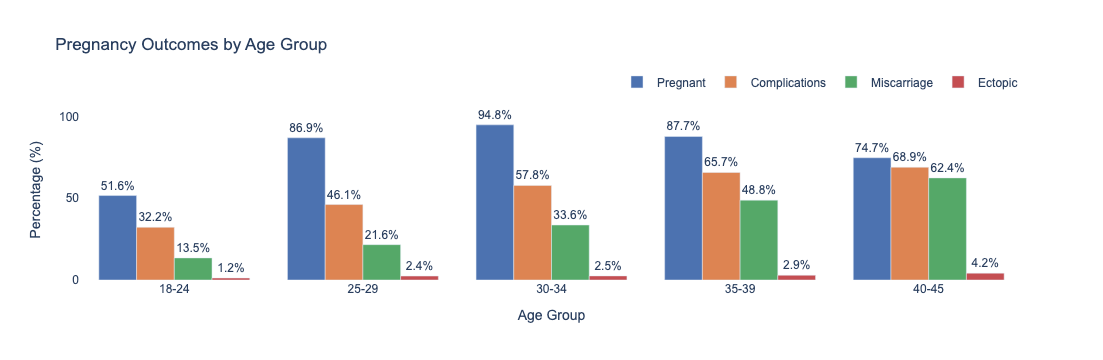

In [51]:
import plotly.graph_objects as go

# ── VIZ 1: Pregnancy Outcomes by Age Group ────────────────────────────────
fig1 = go.Figure()

metrics = {
    "Pregnant":          "pct_pregnant",
    "Complications":     "pct_complicated",
    "Miscarriage":       "pct_miscarriage",
    "Ectopic":           "pct_ectopic",
}

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for (label, col), color in zip(metrics.items(), colors):
    fig1.add_trace(go.Bar(
        name=label,
        x=pregnancy_outcomes["age_group"],
        y=pregnancy_outcomes[col],
        marker_color=color,
        text=pregnancy_outcomes[col].astype(str) + "%",
        textposition="outside",
    ))

fig1.update_layout(
    title="Pregnancy Outcomes by Age Group",
    xaxis_title="Age Group",
    yaxis_title="Percentage (%)",
    barmode="group",
    yaxis=dict(range=[0, 110]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    plot_bgcolor="white",
    font=dict(family="Arial", size=12),
)

fig1.show()

### 6.2 Reproductive Health Condition Distribution

Horizontal bar chart showing the number of pregnant patients affected by each 
reproductive health condition. Anemia dominates due to Synthea's broad application 
of the general anemia code — see limitations.

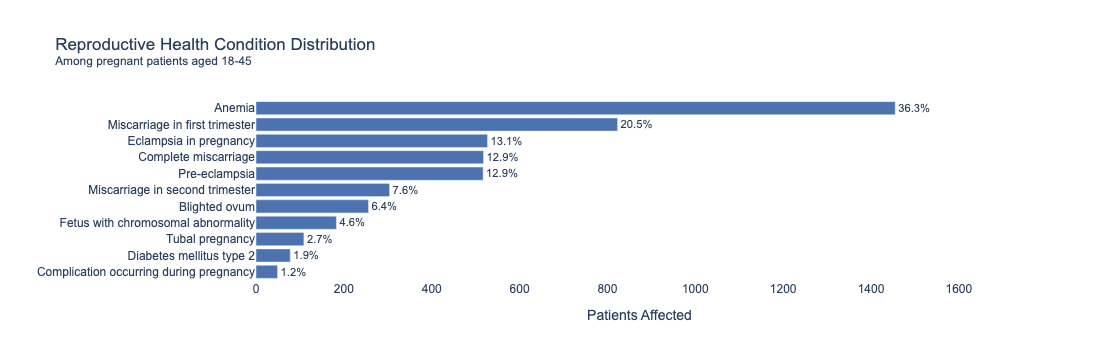

In [52]:
# ── VIZ 2: Condition Distribution ─────────────────────────────────────────
fig2 = go.Figure()

fig2.add_trace(go.Bar(
    orientation="h",
    x=complication_dist["patients_affected"],
    y=complication_dist["DESCRIPTION"].str.replace(r"\s*\(.*?\)", "", regex=True),
    marker_color="#4C72B0",
    text=complication_dist["pct_of_pregnant"].astype(str) + "%",
    textposition="outside",
))

fig2.update_layout(
    title="Reproductive Health Condition Distribution<br><sup>Among pregnant patients aged 18-45</sup>",
    xaxis_title="Patients Affected",
    yaxis_title="",
    yaxis=dict(autorange="reversed"),
    xaxis=dict(range=[0, complication_dist["patients_affected"].max() * 1.2]),
    plot_bgcolor="white",
    font=dict(family="Arial", size=12),
    margin=dict(l=250),
)

fig2.show()

### 6.3 Miscarriage Rate vs CDC/ACOG Benchmarks

Line chart comparing Synthea-generated miscarriage rates against real-world 
benchmarks from CDC and ACOG. While the age-related trend is directionally correct, 
Synthea over-generates pregnancy loss across all age groups.

Sources: ACOG Early Pregnancy Loss (2023); Magnus et al. BMJ (2019).

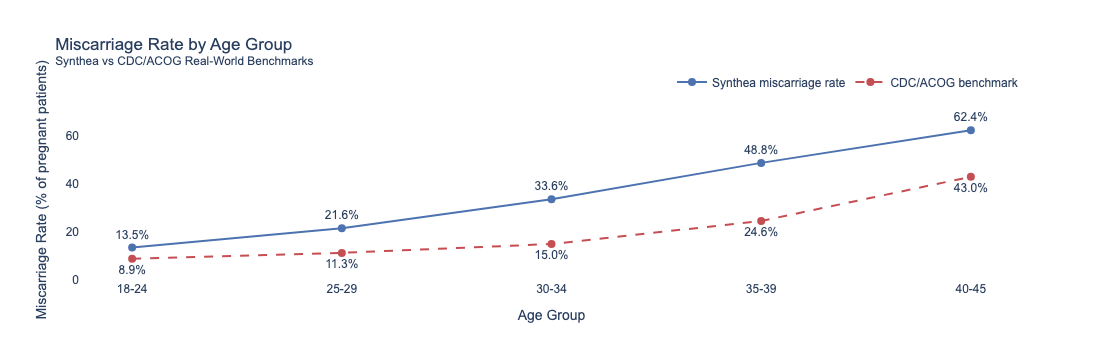

In [54]:
# ── VIZ 3: Miscarriage Rate by Age Group ──────────────────────────────────
fig3 = go.Figure()

fig3.add_trace(go.Scatter(
    x=miscarriage_rates["age_group"],
    y=miscarriage_rates["rate_of_pregnant"],
    mode="lines+markers+text",
    name="Synthea miscarriage rate",
    line=dict(color="#4C72B0", width=2),
    marker=dict(size=8),
    text=miscarriage_rates["rate_of_pregnant"].astype(str) + "%",
    textposition="top center",
))

# Real-world benchmark ranges by age group (ACOG/CDC)
real_world = {
    "18-24": 8.9,
    "25-29": 11.3,
    "30-34": 15.0,
    "35-39": 24.6,
    "40-45": 43.0,
}

fig3.add_trace(go.Scatter(
    x=list(real_world.keys()),
    y=list(real_world.values()),
    mode="lines+markers+text",
    name="CDC/ACOG benchmark",
    line=dict(color="#C44E52", width=2, dash="dash"),
    marker=dict(size=8),
    text=[f"{v}%" for v in real_world.values()],
    textposition="bottom center",
))

fig3.update_layout(
    title="Miscarriage Rate by Age Group<br><sup>Synthea vs CDC/ACOG Real-World Benchmarks</sup>",
    xaxis_title="Age Group",
    yaxis_title="Miscarriage Rate (% of pregnant patients)",
    yaxis=dict(range=[0, 75]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    plot_bgcolor="white",
    font=dict(family="Arial", size=12),
)

fig3.show()

### 6.4 Eclampsia & Pre-Eclampsia vs CDC/WHO Benchmarks

Grouped bar chart directly visualizing the impact of the Synthea pregnancy module 
bug. In a corrected dataset, pre-eclampsia should appear at 5–7% and eclampsia 
at 0.016–0.1% of pregnancies. The near-equal rates in this dataset reflect the 
pre-fix data quality issue.

Sources: CDC (2022); WHO (2025); Fishel Bartal & Sibai, AJOG (2022).

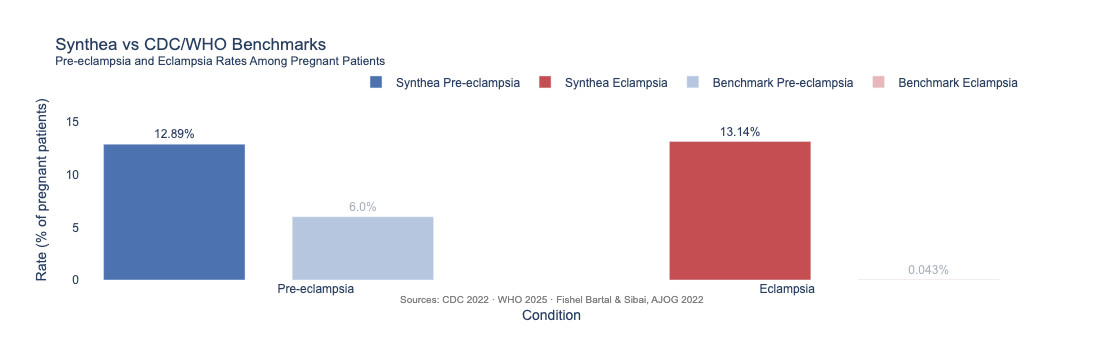

In [95]:
# ── VIZ 4: Eclampsia Rate vs CDC Benchmark ────────────────────────────────
ec_rate = round(100.0 * ec_count / pregnant, 2)
pe_rate = round(100.0 * pe_count / pregnant, 2)

fig4 = go.Figure()

# Synthea pre-eclampsia
fig4.add_trace(go.Bar(
    name="Synthea Pre-eclampsia",
    x=["Pre-eclampsia"],
    y=[pe_rate],
    marker_color="#4C72B0",
    text=[f"{pe_rate}%"],
    textposition="outside",
    width=0.3,
))

# Synthea eclampsia
fig4.add_trace(go.Bar(
    name="Synthea Eclampsia",
    x=["Eclampsia"],
    y=[ec_rate],
    marker_color="#C44E52",
    text=[f"{ec_rate}%"],
    textposition="outside",
    width=0.3,
))

# Benchmark pre-eclampsia
fig4.add_trace(go.Bar(
    name="Benchmark Pre-eclampsia",
    x=["Pre-eclampsia"],
    y=[6.0],
    marker_color="#4C72B0",
    opacity=0.4,
    text=["6.0%"],
    textposition="outside",
    width=0.3,
))

# Benchmark eclampsia
fig4.add_trace(go.Bar(
    name="Benchmark Eclampsia",
    x=["Eclampsia"],
    y=[0.043],
    marker_color="#C44E52",
    opacity=0.4,
    text=["0.043%"],
    textposition="outside",
    width=0.3,
))



fig4.update_layout(
    title="Synthea vs CDC/WHO Benchmarks<br><sup>Pre-eclampsia and Eclampsia Rates Among Pregnant Patients</sup>",
    xaxis_title="Condition",
    yaxis_title="Rate (% of pregnant patients)",
    barmode="group",
    yaxis=dict(range=[0, max(pe_rate, ec_rate) * 1.3]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    plot_bgcolor="white",
    font=dict(family="Arial", size=12),
    annotations=[
        dict(
            x=0.5, y=-0.15,
            xref="paper", yref="paper",
            text="Sources: CDC 2022 · WHO 2025 · Fishel Bartal & Sibai, AJOG 2022",
            showarrow=False,
            font=dict(size=10, color="gray"),
        )
    ]
)

fig4.show()

## 7. Pregnancy Care Journey

### 7.1 Data Preparation

Patient journeys are reconstructed from encounter sequences. Patients are categorized 
into mutually exclusive outcome groups — pregnancy loss, delivery, or no recorded 
outcome — all scoped strictly to patients who attended ongoing prenatal visits.

> **Note:** Synthea routes many deliveries through obstetric emergency encounters 
> rather than dedicated delivery encounter types, which is a known limitation of 
> the synthetic data model.

In [58]:
# ── EXPLORE: Encounters for pregnant patients ─────────────────────────────
encounter_codes = pd.read_sql("""
    SELECT
        e.ENCOUNTERCLASS,
        e.CODE,
        e.DESCRIPTION,
        COUNT(*) as count
    FROM raw_encounters e
    INNER JOIN patient_flags pf ON e.PATIENT = pf.Id
    WHERE pf.pregnancy_flag = 1
    GROUP BY e.ENCOUNTERCLASS, e.CODE, e.DESCRIPTION
    ORDER BY count DESC
    LIMIT 40
""", conn)

print(encounter_codes.to_string(index=False))

ENCOUNTERCLASS            CODE                                                            DESCRIPTION  count
    ambulatory       424619006                                        Prenatal visit (regime/therapy)  58188
      wellness       162673000                             General examination of patient (procedure)  27236
    outpatient       308335008                                Patient encounter procedure (procedure)  20085
    outpatient       698314001                                 Consultation for treatment (procedure)  17550
    ambulatory       185349003                                     Encounter for check up (procedure)  15272
    ambulatory       185345009                                      Encounter for symptom (procedure)  13286
    ambulatory       185347001                                      Encounter for problem (procedure)  11773
    ambulatory       424441002                                Prenatal initial visit (regime/therapy)  10665
    ambulatory     

In [60]:
# ── INSPECT: Sample patient with pregnancy ────────────────────────────────
pregnancy_patient = pd.read_sql("""
    SELECT e.PATIENT, e.START, e.STOP, e.ENCOUNTERCLASS, e.CODE, e.DESCRIPTION
    FROM raw_encounters e
    INNER JOIN patient_flags pf ON e.PATIENT = pf.Id
    WHERE pf.pregnancy_flag = 1
    AND pf.miscarriage_flag = 0
    AND pf.ectopic_flag = 0
    LIMIT 1
""", conn)

sample_id = pregnancy_patient["PATIENT"].iloc[0]

pd.read_sql(f"""
    SELECT e.START, e.STOP, e.ENCOUNTERCLASS, e.DESCRIPTION
    FROM raw_encounters e
    WHERE e.PATIENT = '{sample_id}'
    ORDER BY e.START
""", conn)

,START,STOP,ENCOUNTERCLASS,DESCRIPTION
0,2015-10-21T14:27:08Z,2015-10-21T14:42:08Z,outpatient,Encounter for problem (procedure)
1,2015-11-09T14:27:08Z,2015-11-09T14:58:08Z,wellness,General examination of patient (procedure)
2,2016-03-02T20:27:08Z,2016-03-02T20:42:08Z,ambulatory,Encounter for symptom (procedure)
3,2016-08-19T14:27:08Z,2016-08-19T14:42:08Z,outpatient,Consultation for treatment (procedure)
4,2016-11-14T14:27:08Z,2016-11-14T15:25:13Z,wellness,General examination of patient (procedure)
5,2017-02-19T16:27:08Z,2017-02-19T16:42:08Z,ambulatory,Encounter for symptom (procedure)
6,2017-08-14T14:27:08Z,2017-08-14T14:42:08Z,outpatient,Consultation for treatment (procedure)
7,2017-11-20T14:27:08Z,2017-11-20T15:21:03Z,wellness,General examination of patient (procedure)
8,2017-12-04T14:27:08Z,2017-12-04T17:58:53Z,ambulatory,Encounter for check up (procedure)
9,2018-11-26T14:27:08Z,2018-11-26T15:17:44Z,wellness,General examination of patient (procedure)


In [65]:
# ── INSPECT: Full journey for sample pregnancy patient ────────────────────
print("=== ENCOUNTERS ===")
display(pd.read_sql(f"""
    SELECT START, STOP, ENCOUNTERCLASS, DESCRIPTION
    FROM raw_encounters
    WHERE PATIENT = '{sample_id}'
    ORDER BY START
""", conn))

print("=== CONDITIONS ===")
display(pd.read_sql(f"""
    SELECT START, STOP, CODE, DESCRIPTION
    FROM raw_conditions
    WHERE PATIENT = '{sample_id}'
    ORDER BY START
""", conn))

print("=== PROCEDURES ===")
display(pd.read_sql(f"""
    SELECT START, STOP, CODE, DESCRIPTION
    FROM raw_procedures
    WHERE PATIENT = '{sample_id}'
    ORDER BY START
""", conn))

print("=== MEDICATIONS ===")
display(pd.read_sql(f"""
    SELECT START, STOP, CODE, DESCRIPTION
    FROM raw_medications
    WHERE PATIENT = '{sample_id}'
    ORDER BY START
""", conn))

print("=== CARE PLANS ===")
display(pd.read_sql(f"""
    SELECT START, STOP, CODE, DESCRIPTION
    FROM raw_careplans
    WHERE PATIENT = '{sample_id}'
    ORDER BY START
""", conn))

=== ENCOUNTERS ===


,START,STOP,ENCOUNTERCLASS,DESCRIPTION
0,2015-10-21T14:27:08Z,2015-10-21T14:42:08Z,outpatient,Encounter for problem (procedure)
1,2015-11-09T14:27:08Z,2015-11-09T14:58:08Z,wellness,General examination of patient (procedure)
2,2016-03-02T20:27:08Z,2016-03-02T20:42:08Z,ambulatory,Encounter for symptom (procedure)
3,2016-08-19T14:27:08Z,2016-08-19T14:42:08Z,outpatient,Consultation for treatment (procedure)
4,2016-11-14T14:27:08Z,2016-11-14T15:25:13Z,wellness,General examination of patient (procedure)
5,2017-02-19T16:27:08Z,2017-02-19T16:42:08Z,ambulatory,Encounter for symptom (procedure)
6,2017-08-14T14:27:08Z,2017-08-14T14:42:08Z,outpatient,Consultation for treatment (procedure)
7,2017-11-20T14:27:08Z,2017-11-20T15:21:03Z,wellness,General examination of patient (procedure)
8,2017-12-04T14:27:08Z,2017-12-04T17:58:53Z,ambulatory,Encounter for check up (procedure)
9,2018-11-26T14:27:08Z,2018-11-26T15:17:44Z,wellness,General examination of patient (procedure)


=== CONDITIONS ===


,START,STOP,CODE,DESCRIPTION
0,2015-10-21,None,82423001,Chronic pain (finding)
1,2015-10-21,None,278860009,Chronic low back pain (finding)
2,2015-11-09,None,224299000,Received higher education (finding)
3,2015-11-09,2017-11-20,160904001,Part-time employment (finding)
4,2015-11-09,2016-11-14,73595000,Stress (finding)
5,2016-03-02,2016-03-16,444814009,Viral sinusitis (disorder)
6,2016-11-14,2016-11-14,314529007,Medication review due (situation)
7,2017-02-19,2017-03-03,444814009,Viral sinusitis (disorder)
8,2017-11-20,2018-11-26,314529007,Medication review due (situation)
9,2017-11-20,2018-11-26,73438004,Unemployed (finding)


=== PROCEDURES ===


,START,STOP,CODE,DESCRIPTION
0,2016-11-14T14:27:08Z,2016-11-14T14:42:08Z,430193006,Medication reconciliation (procedure)
1,2016-11-14T14:27:08Z,2016-11-14T15:25:13Z,710824005,Assessment of health and social care needs (pr...
2,2016-11-14T15:25:13Z,2016-11-14T15:46:21Z,710841007,Assessment of anxiety (procedure)
3,2016-11-14T15:46:21Z,2016-11-14T15:58:39Z,171207006,Depression screening (procedure)
4,2016-11-14T15:58:39Z,2016-11-14T16:26:28Z,171207006,Depression screening (procedure)
...,...,...,...,...
129,2026-01-05T15:12:43Z,2026-01-05T15:32:26Z,710841007,Assessment of anxiety (procedure)
130,2026-01-05T15:32:26Z,2026-01-05T15:44:25Z,171207006,Depression screening (procedure)
131,2026-01-05T15:44:25Z,2026-01-05T16:13:18Z,171207006,Depression screening (procedure)
132,2026-01-05T16:13:18Z,2026-01-05T16:24:27Z,428211000124100,Assessment of substance use (procedure)


=== MEDICATIONS ===


,START,STOP,CODE,DESCRIPTION
0,2015-11-09T14:27:08Z,2016-11-14T14:27:08Z,209387,Acetaminophen 325 MG Oral Tablet [Tylenol]
1,2016-08-19T14:27:08Z,2017-08-14T14:27:08Z,749762,{7 (ethinyl estradiol 0.01 MG Oral Tablet) / 8...
2,2016-11-14T14:27:08Z,2017-11-20T14:27:08Z,209387,Acetaminophen 325 MG Oral Tablet [Tylenol]
3,2017-08-14T14:27:08Z,2018-08-09T14:27:08Z,748879,{21 (ethinyl estradiol 0.03 MG / levonorgestre...
4,2017-11-20T14:27:08Z,2018-11-26T14:27:08Z,209387,Acetaminophen 325 MG Oral Tablet [Tylenol]
5,2017-12-04T17:04:53Z,2017-12-04T17:04:53Z,1535362,sodium fluoride 0.0272 MG/MG Oral Gel
6,2018-11-26T14:27:08Z,2019-12-02T14:27:08Z,209387,Acetaminophen 325 MG Oral Tablet [Tylenol]
7,2019-12-02T14:27:08Z,2020-12-07T14:27:08Z,209387,Acetaminophen 325 MG Oral Tablet [Tylenol]
8,2019-12-16T17:18:21Z,2019-12-16T17:18:21Z,1535362,sodium fluoride 0.0272 MG/MG Oral Gel
9,2020-07-29T14:27:08Z,2021-07-24T14:27:08Z,978950,{5 (dienogest 2 MG / estradiol valerate 2 MG O...


=== CARE PLANS ===


,START,STOP,CODE,DESCRIPTION
0,2019-10-28,2020-06-15,134435003,Routine antenatal care (regime/therapy)


In [67]:
# ── INSPECT: Full journey for sample loss patient ─────────────────────────

loss_patient = pd.read_sql("""
    SELECT e.PATIENT, e.START, e.STOP, e.ENCOUNTERCLASS, e.CODE, e.DESCRIPTION
    FROM raw_encounters e
    INNER JOIN patient_flags pf ON e.PATIENT = pf.Id
    WHERE pf.pregnancy_flag = 1
    AND pf.miscarriage_flag = 1
    LIMIT 1
""", conn)

loss_id = loss_patient["PATIENT"].iloc[0]

print("=== ENCOUNTERS ===")
display(pd.read_sql(f"""
    SELECT START, STOP, ENCOUNTERCLASS, DESCRIPTION
    FROM raw_encounters
    WHERE PATIENT = '{loss_id}'
    ORDER BY START
""", conn))

print("=== CONDITIONS ===")
display(pd.read_sql(f"""
    SELECT START, STOP, CODE, DESCRIPTION
    FROM raw_conditions
    WHERE PATIENT = '{loss_id}'
    ORDER BY START
""", conn))

print("=== CARE PLANS ===")
display(pd.read_sql(f"""
    SELECT START, STOP, CODE, DESCRIPTION
    FROM raw_careplans
    WHERE PATIENT = '{loss_id}'
    ORDER BY START
""", conn))

=== ENCOUNTERS ===


,START,STOP,ENCOUNTERCLASS,DESCRIPTION
0,2011-08-04T15:44:18Z,2011-08-04T16:33:57Z,wellness,General examination of patient (procedure)
1,2012-08-09T15:44:18Z,2012-08-09T16:23:23Z,wellness,General examination of patient (procedure)
2,2015-05-12T15:44:18Z,2015-05-12T15:59:18Z,outpatient,Consultation for treatment (procedure)
3,2015-08-13T15:44:18Z,2015-08-13T16:40:47Z,wellness,General examination of patient (procedure)
4,2016-05-06T15:44:18Z,2016-05-06T15:59:18Z,outpatient,Consultation for treatment (procedure)
5,2018-08-16T15:44:18Z,2018-08-16T16:17:17Z,wellness,General examination of patient (procedure)
6,2019-01-10T15:44:18Z,2019-01-10T15:59:18Z,ambulatory,Prenatal initial visit (regime/therapy)
7,2019-01-30T15:44:18Z,2019-01-30T15:59:18Z,ambulatory,Prenatal visit (regime/therapy)
8,2019-04-21T15:44:18Z,2019-04-21T16:35:44Z,outpatient,Consultation for treatment (procedure)
9,2019-05-02T16:35:44Z,2019-05-03T16:35:44Z,inpatient,Admission to surgical department (procedure)


=== CONDITIONS ===


,START,STOP,CODE,DESCRIPTION
0,2011-08-04,None,224299000,Received higher education (finding)
1,2012-08-09,2018-08-16,160904001,Part-time employment (finding)
2,2015-08-13,None,73595000,Stress (finding)
3,2018-08-16,2024-08-22,314529007,Medication review due (situation)
4,2018-08-16,None,160903007,Full-time employment (finding)
5,2018-08-16,2021-08-19,423315002,Limited social contact (finding)
6,2019-01-10,2019-01-30,72892002,Normal pregnancy (finding)
7,2019-01-10,2019-01-30,19169002,Miscarriage in first trimester (disorder)
8,2019-01-10,2019-01-30,35999006,Blighted ovum (disorder)
9,2019-01-30,None,161744009,Past pregnancy history of miscarriage (situation)


=== CARE PLANS ===


,START,STOP,CODE,DESCRIPTION
0,2019-05-02,2019-05-17,737471002,Minor surgery care management (procedure)


In [83]:
# ── SANKEY: Query and variable prep ───────────────────────────────────────
sankey_counts = pd.read_sql("""
    WITH continued AS (
        SELECT DISTINCT e.PATIENT
        FROM raw_encounters e
        INNER JOIN patient_flags pf ON e.PATIENT = pf.Id
        WHERE pf.pregnancy_flag = 1
        AND e.CODE = 424619006
    ),
    loss AS (
        SELECT DISTINCT pf.Id AS PATIENT
        FROM patient_flags pf
        INNER JOIN continued c ON pf.Id = c.PATIENT
        WHERE pf.miscarriage_flag = 1 OR pf.ectopic_flag = 1
    ),
    delivered AS (
        SELECT DISTINCT e.PATIENT
        FROM raw_encounters e
        INNER JOIN continued c ON e.PATIENT = c.PATIENT
        WHERE e.CODE = 183460006
    ),
    loss_only AS (
        SELECT l.PATIENT FROM loss l
        LEFT JOIN delivered d ON l.PATIENT = d.PATIENT
        WHERE d.PATIENT IS NULL
    ),
    both AS (
        SELECT l.PATIENT FROM loss l
        INNER JOIN delivered d ON l.PATIENT = d.PATIENT
    ),
    delivery_only AS (
        SELECT d.PATIENT FROM delivered d
        LEFT JOIN loss l ON d.PATIENT = l.PATIENT
        WHERE l.PATIENT IS NULL
    ),
    neither AS (
        SELECT c.PATIENT FROM continued c
        LEFT JOIN loss l ON c.PATIENT = l.PATIENT
        LEFT JOIN delivered d ON c.PATIENT = d.PATIENT
        WHERE l.PATIENT IS NULL AND d.PATIENT IS NULL
    ),
    postnatal_delivery_only AS (
        SELECT DISTINCT e.PATIENT
        FROM raw_encounters e
        INNER JOIN delivery_only d ON e.PATIENT = d.PATIENT
        WHERE e.CODE = 169762003
    ),
    surgical_loss_only AS (
        SELECT DISTINCT e.PATIENT
        FROM raw_encounters e
        INNER JOIN loss_only l ON e.PATIENT = l.PATIENT
        WHERE e.ENCOUNTERCLASS = 'inpatient'
    ),
    surgical_both AS (
        SELECT DISTINCT e.PATIENT
        FROM raw_encounters e
        INNER JOIN both b ON e.PATIENT = b.PATIENT
        WHERE e.ENCOUNTERCLASS = 'inpatient'
    )

    SELECT
        (SELECT COUNT(*) FROM continued)               AS continued,
        (SELECT COUNT(*) FROM loss_only)               AS loss_only,
        (SELECT COUNT(*) FROM both)                    AS both,
        (SELECT COUNT(*) FROM delivery_only)           AS delivery_only,
        (SELECT COUNT(*) FROM neither)                 AS neither,
        (SELECT COUNT(*) FROM postnatal_delivery_only) AS postnatal_delivery_only,
        (SELECT COUNT(*) FROM surgical_loss_only)      AS surgical_loss_only,
        (SELECT COUNT(*) FROM surgical_both)           AS surgical_both
""", conn)

# Dynamic variables
continued      = int(sankey_counts["continued"].iloc[0])
loss_only      = int(sankey_counts["loss_only"].iloc[0])
both           = int(sankey_counts["both"].iloc[0])
delivery_only  = int(sankey_counts["delivery_only"].iloc[0])
neither        = int(sankey_counts["neither"].iloc[0])
postnatal_del  = int(sankey_counts["postnatal_delivery_only"].iloc[0])
surgical_loss  = int(sankey_counts["surgical_loss_only"].iloc[0])
surgical_both  = int(sankey_counts["surgical_both"].iloc[0])
no_continued   = pregnant - continued

### 7.2 Pregnancy Care Journey — Sankey Diagram

The Sankey diagram traces patient flow from pregnancy through prenatal care attendance 
to final outcomes. Hover over nodes and links for patient counts.

- **Blue** — prenatal care pathway  
- **Red** — pregnancy loss  
- **Green** — delivery and postnatal care  
- **Orange** — surgical follow-up  
- **Grey** — no further care or no recorded outcome 

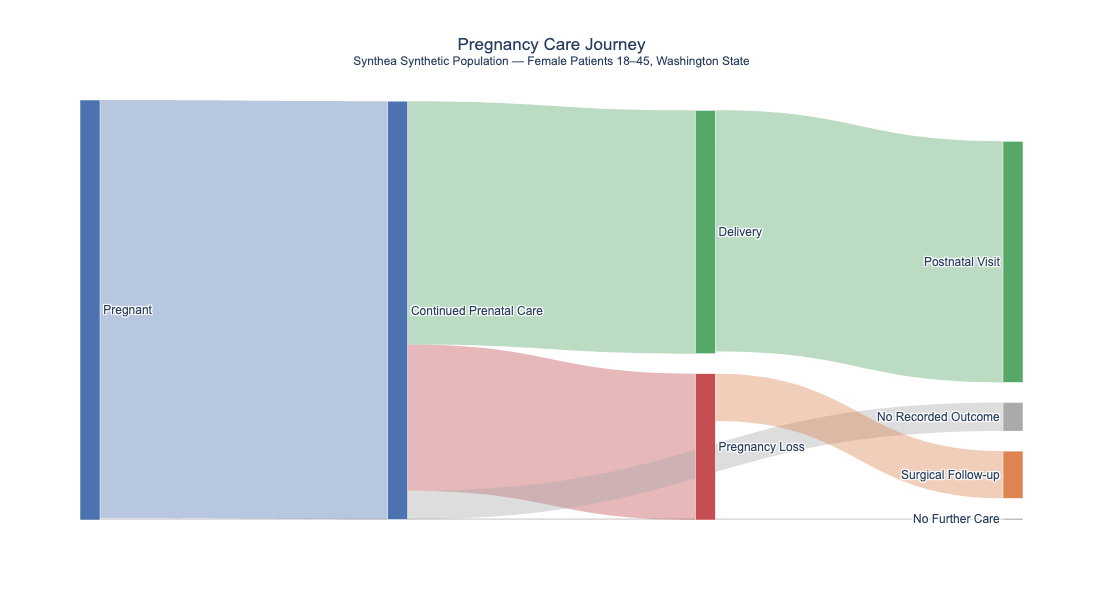

In [84]:
# ── VIZ 5: Pregnancy Journey Sankey Diagram ───────────────────────────────
labels = [
    "Pregnant",                # 0
    "Continued Prenatal Care", # 1
    "No Further Care",         # 2
    "Pregnancy Loss",          # 3
    "Delivery",                # 4
    "No Recorded Outcome",     # 5
    "Postnatal Visit",         # 6
    "Surgical Follow-up",      # 7
]

sources = [0, 0, 1, 1, 1, 4, 3]
targets = [1, 2, 3, 4, 5, 6, 7]
values  = [
    continued,                     # Pregnant -> Continued
    no_continued,                  # Pregnant -> No Further Care
    loss_only + both,              # Continued -> Pregnancy Loss
    delivery_only,                 # Continued -> Delivery
    neither,                       # Continued -> No Recorded Outcome
    postnatal_del,                 # Delivery -> Postnatal
    surgical_loss + surgical_both, # Loss -> Surgical Follow-up
]

colors_node = [
    "#4C72B0",  # Pregnant
    "#4C72B0",  # Continued
    "#aaaaaa",  # No Further Care
    "#C44E52",  # Pregnancy Loss
    "#55A868",  # Delivery
    "#aaaaaa",  # No Recorded Outcome
    "#55A868",  # Postnatal
    "#DD8452",  # Surgical
]

colors_link = [
    "rgba(76, 114, 176, 0.4)",   # Pregnant -> Continued
    "rgba(170, 170, 170, 0.4)",  # Pregnant -> No Further Care
    "rgba(196, 78, 82, 0.4)",    # Continued -> Loss
    "rgba(85, 168, 104, 0.4)",   # Continued -> Delivery
    "rgba(170, 170, 170, 0.4)",  # Continued -> No Recorded Outcome
    "rgba(85, 168, 104, 0.4)",   # Delivery -> Postnatal
    "rgba(221, 132, 82, 0.4)",   # Loss -> Surgical
]

fig5 = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="white", width=0.5),
        label=labels,
        color=colors_node,
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=colors_link,
    )
))

fig5.update_layout(
    title=dict(
        text="Pregnancy Care Journey<br><sup>Synthea Synthetic Population — Female Patients 18–45, Washington State</sup>",
        x=0.5,
    ),
    font=dict(family="Arial", size=12),
    height=600,
)

fig5.show()